Datasets loaded successfully!

--- Crop Recommendation Dataset Analysis ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB
None

Description of the dataset:
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min 

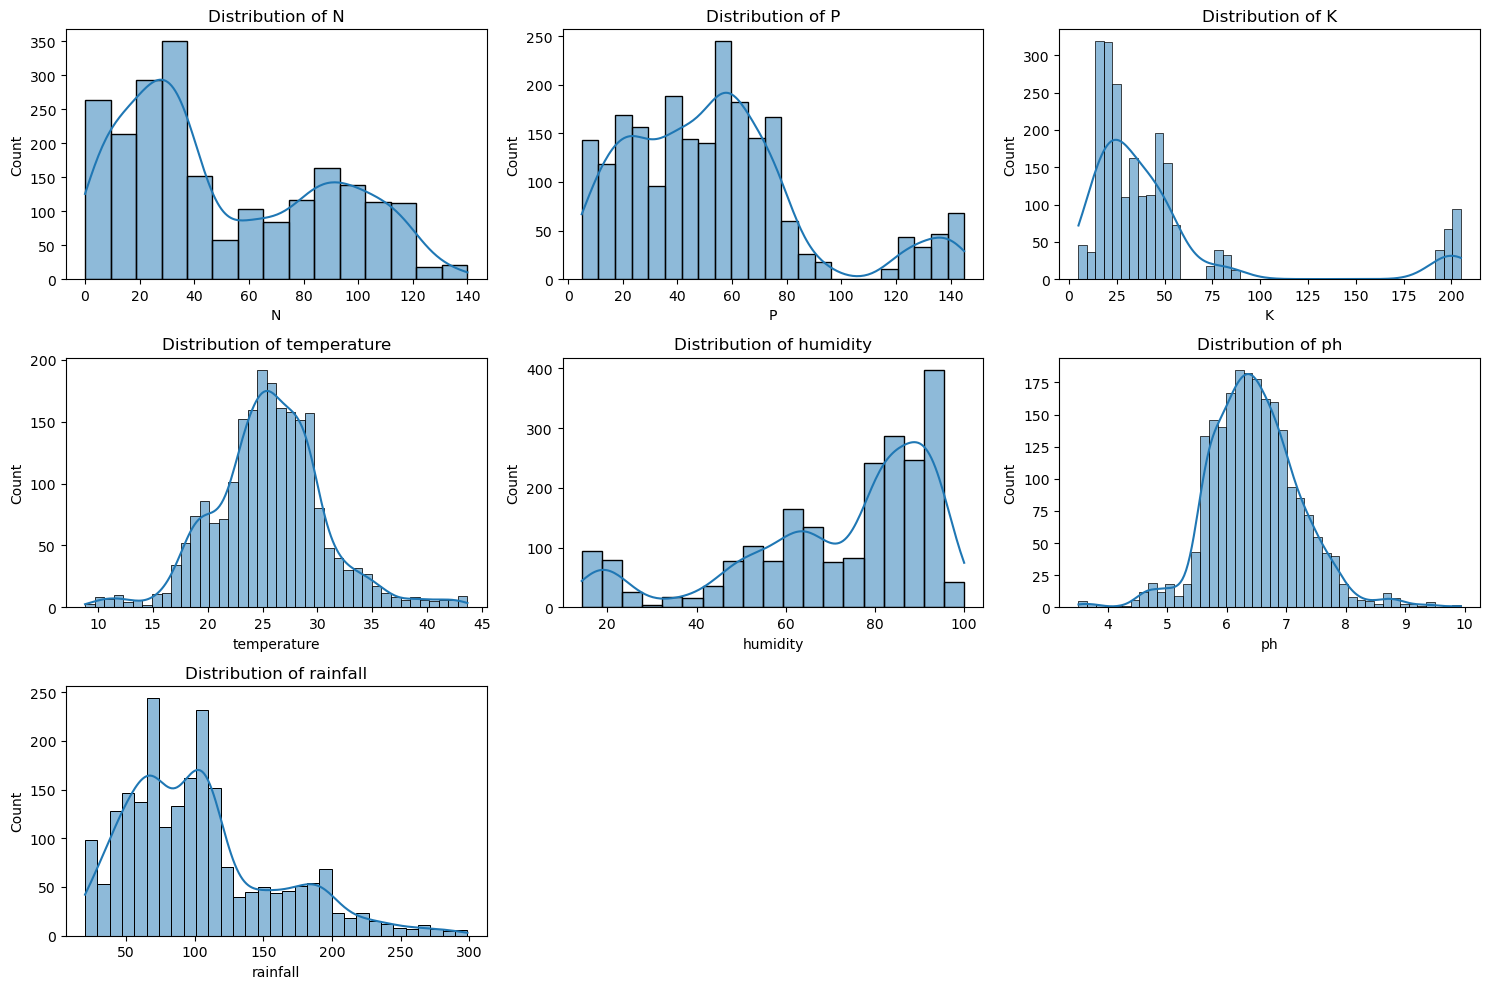

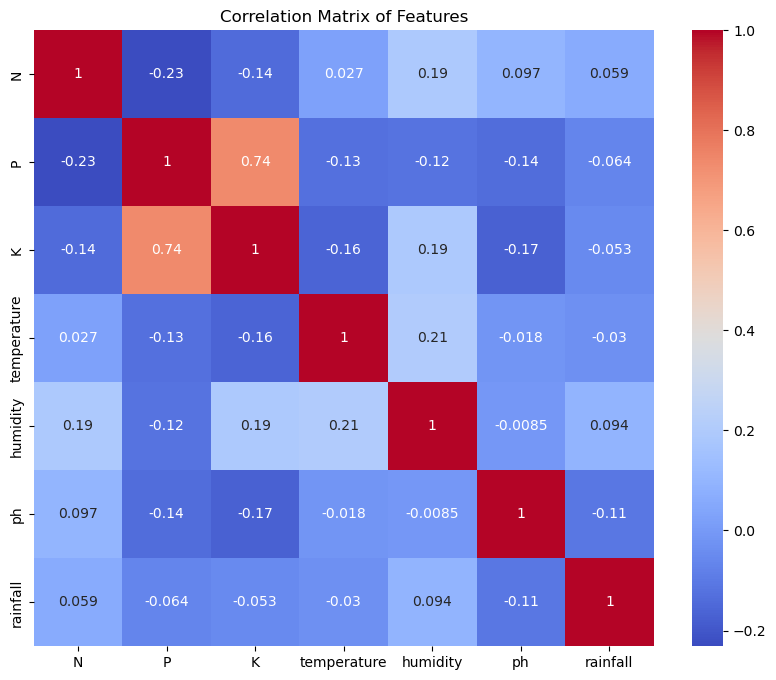

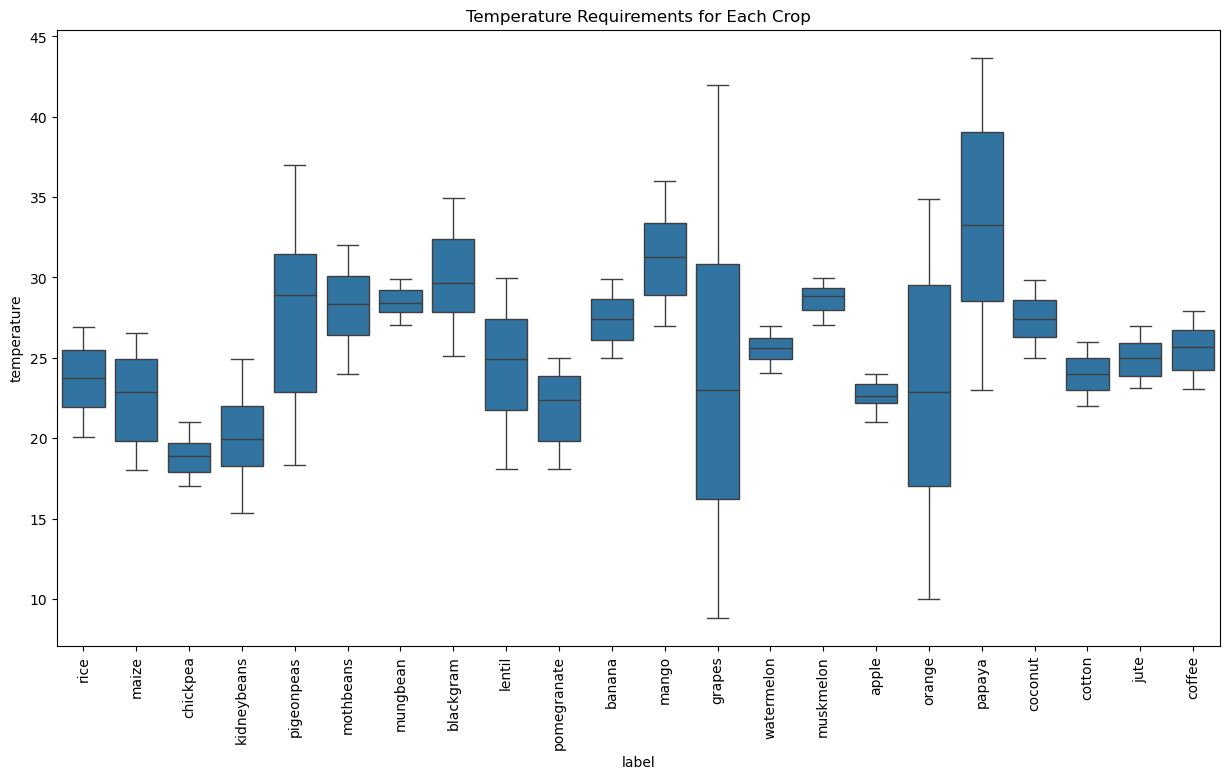


--- Fertilizer Recommendation Dataset Analysis ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99 entries, 0 to 98
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Temparature      99 non-null     int64 
 1   Humidity         99 non-null     int64 
 2   Soil Moisture    99 non-null     int64 
 3   Soil Type        99 non-null     object
 4   Crop Type        99 non-null     object
 5   Nitrogen         99 non-null     int64 
 6   Potassium        99 non-null     int64 
 7   Phosphorous      99 non-null     int64 
 8   Fertilizer Name  99 non-null     object
dtypes: int64(6), object(3)
memory usage: 7.1+ KB
None

Unique Soil Types: ['Sandy' 'Loamy' 'Black' 'Red' 'Clayey']
Unique Crop Types: ['Maize' 'Sugarcane' 'Cotton' 'Tobacco' 'Paddy' 'Barley' 'Wheat' 'Millets'
 'Oil seeds' 'Pulses' 'Ground Nuts']

--- Rainfall Dataset Analysis ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4116 entries, 0 to 

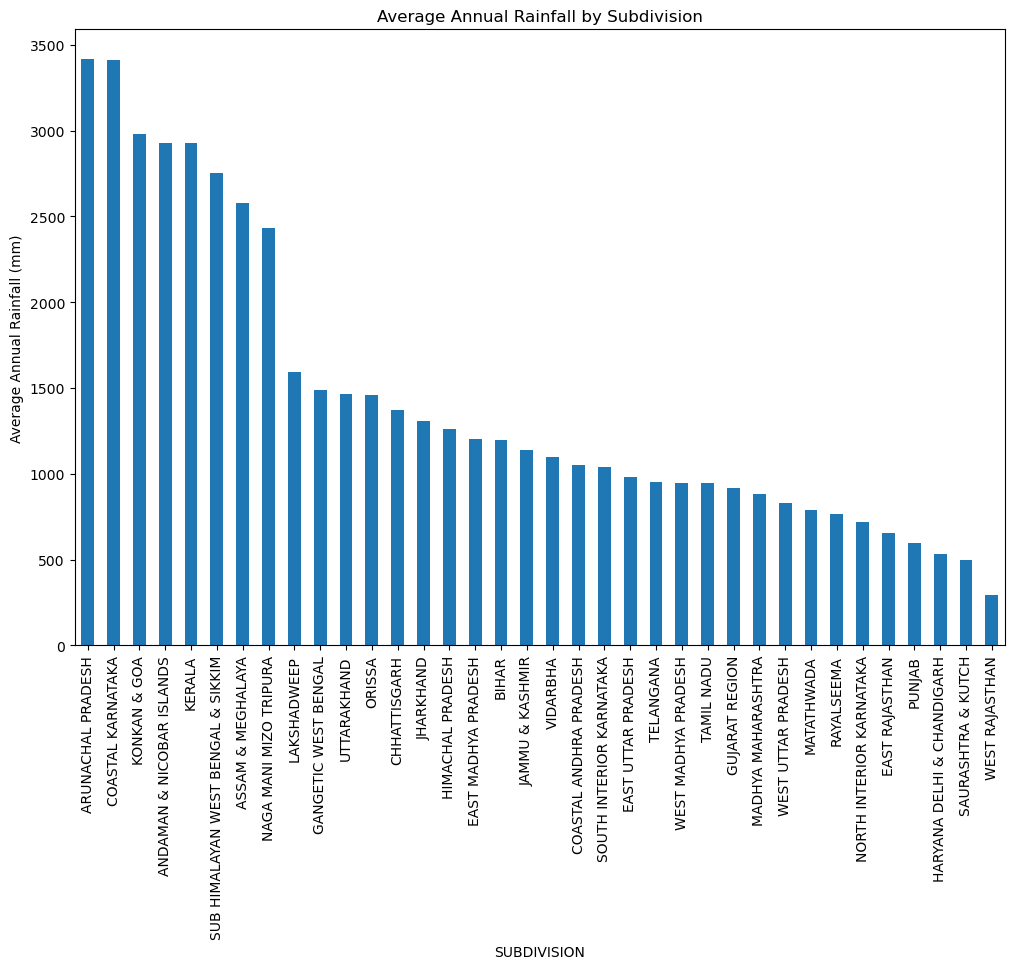


--- Crop Production Dataset Analysis ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     246091 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB
None


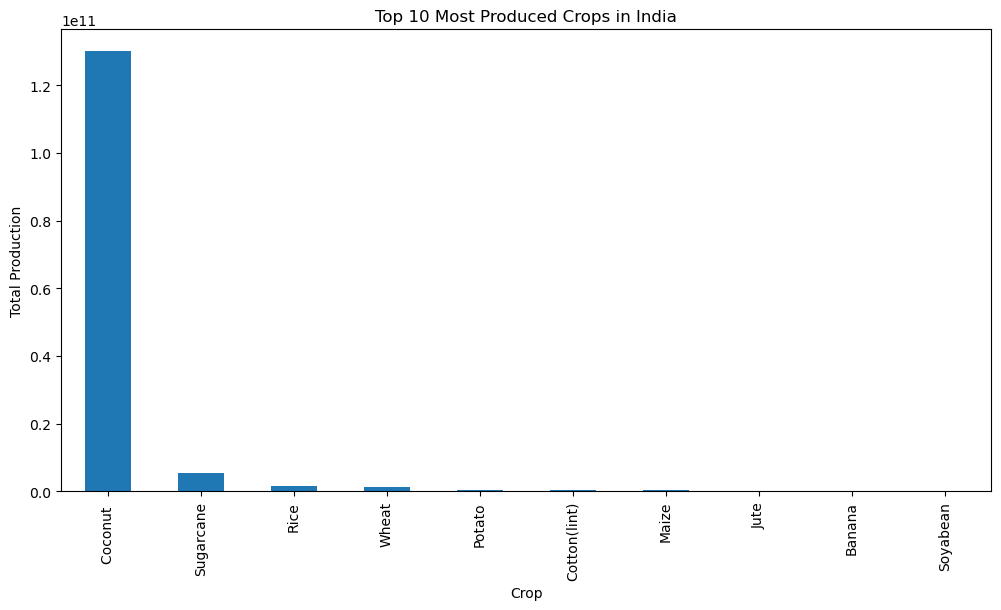

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the datasets
try:
    crop_recommendation_df = pd.read_csv('Crop_recommendation.csv')
    fertilizer_df = pd.read_csv('fertilizer_recommendation.csv')
    rainfall_df = pd.read_csv('rainfall_in_india_1901-2015.csv')
    crop_production_df = pd.read_csv('crop_production_india.csv')

    print("Datasets loaded successfully!")
except FileNotFoundError as e:
    print(f"Error loading datasets: {e}")
    print("Please make sure all the CSV files are in the same directory as the script.")
    exit()


# --- Exploratory Data Analysis for Crop Recommendation ---
print("\n--- Crop Recommendation Dataset Analysis ---")
print(crop_recommendation_df.info())
print("\nDescription of the dataset:")
print(crop_recommendation_df.describe())
print("\nExample rows:")
print(crop_recommendation_df.head())


# Distribution of numerical features
plt.figure(figsize=(15, 10))
for i, col in enumerate(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']):
    plt.subplot(3, 3, i + 1)
    sns.histplot(crop_recommendation_df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = crop_recommendation_df[['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Features')
plt.show()

# Boxplot of temperature for each crop
plt.figure(figsize=(15, 8))
sns.boxplot(x='label', y='temperature', data=crop_recommendation_df)
plt.xticks(rotation=90)
plt.title('Temperature Requirements for Each Crop')
plt.show()


# --- Exploratory Data Analysis for Fertilizer Recommendation ---
print("\n--- Fertilizer Recommendation Dataset Analysis ---")
print(fertilizer_df.info())
print("\nUnique Soil Types:", fertilizer_df['Soil Type'].unique())
print("Unique Crop Types:", fertilizer_df['Crop Type'].unique())

# --- Exploratory Data Analysis for Rainfall Data ---
print("\n--- Rainfall Dataset Analysis ---")
print(rainfall_df.info())
# Average annual rainfall per subdivision
avg_annual_rainfall = rainfall_df.groupby('SUBDIVISION')['ANNUAL'].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 8))
avg_annual_rainfall.plot(kind='bar')
plt.title('Average Annual Rainfall by Subdivision')
plt.ylabel('Average Annual Rainfall (mm)')
plt.show()


# --- Exploratory Data Analysis for Crop Production ---
print("\n--- Crop Production Dataset Analysis ---")
print(crop_production_df.info())
# Top 10 most produced crops
top_10_crops = crop_production_df.groupby('Crop')['Production'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12, 6))
top_10_crops.plot(kind='bar')
plt.title('Top 10 Most Produced Crops in India')
plt.ylabel('Total Production')
plt.show()
